## Learning goals

By the end of this lesson, you should be able to:

- state the maximum-margin criterion and express it as a constrained optimisation;
- read and interpret the primal and dual forms of the SVM;
- explain what a support vector is and why only a few observations determine the boundary; and
- recognise the role of the regularisation parameter $C$ in soft-margin classification.

## 1. The separating hyperplane

Given a binary dataset

$$
\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{N},
\qquad \mathbf{x}_i\in\mathbb{R}^d,\quad y_i\in\{-1,+1\},
$$

a linear classifier assigns labels via the signed decision function

$$
f(\mathbf{x}) = \operatorname{sign}\!\bigl(\mathbf{w}^\top\mathbf{x}+b\bigr),
$$

where $\mathbf{w}\in\mathbb{R}^d$ is the weight vector and $b\in\mathbb{R}$ is the bias.  
The set of points satisfying $\mathbf{w}^\top\mathbf{x}+b=0$ is the **decision hyperplane**.

In [1]:
#| label: setup
#| include: false

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

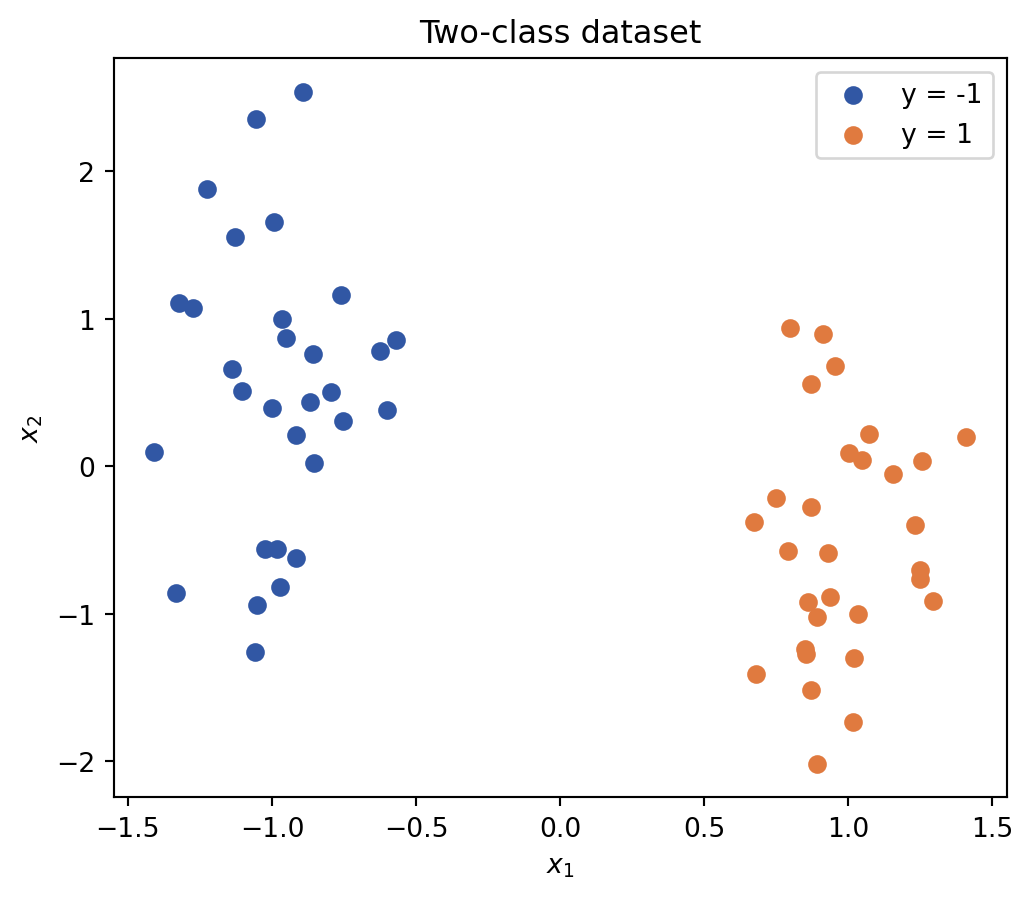

In [2]:
#| label: fig-data
#| fig-cap: "A two-class dataset whose classes are linearly separable."

X, y = make_blobs(n_samples=60, centers=2, cluster_std=0.8, random_state=RANDOM_SEED)
y = 2 * y - 1  # map {0, 1} to {-1, +1}

X = StandardScaler().fit_transform(X)

fig, ax = plt.subplots(figsize=(6, 5))
for lbl, color in [(-1, '#3157a4'), (1, '#e07a3f')]:
    ax.scatter(*X[y == lbl].T, c=color, label=f'y = {lbl}')
ax.set(xlabel='$x_1$', ylabel='$x_2$', title='Two-class dataset')
ax.legend()
plt.show()

## 2. Maximizing the margin

Among all separating hyperplanes, the SVM selects the one that maximises the **geometric margin**—the perpendicular distance from the hyperplane to the nearest observation on each side.

Rescaling $\mathbf{w}$ and $b$ so that the closest observations satisfy

$$
y_i\bigl(\mathbf{w}^\top\mathbf{x}_i+b\bigr)\geq 1,
$$

the two **margin hyperplanes** are $\mathbf{w}^\top\mathbf{x}+b=\pm 1$, and the geometric margin equals $\dfrac{2}{\lVert\mathbf{w}\rVert}$.

Maximising the margin is therefore equivalent to the **primal problem** (hard margin):

$$
\min_{\mathbf{w},\,b}\;\frac{1}{2}\lVert\mathbf{w}\rVert^2
\qquad\text{subject to}\quad
y_i\bigl(\mathbf{w}^\top\mathbf{x}_i+b\bigr)\geq 1,\quad i=1,\ldots,N.
$$

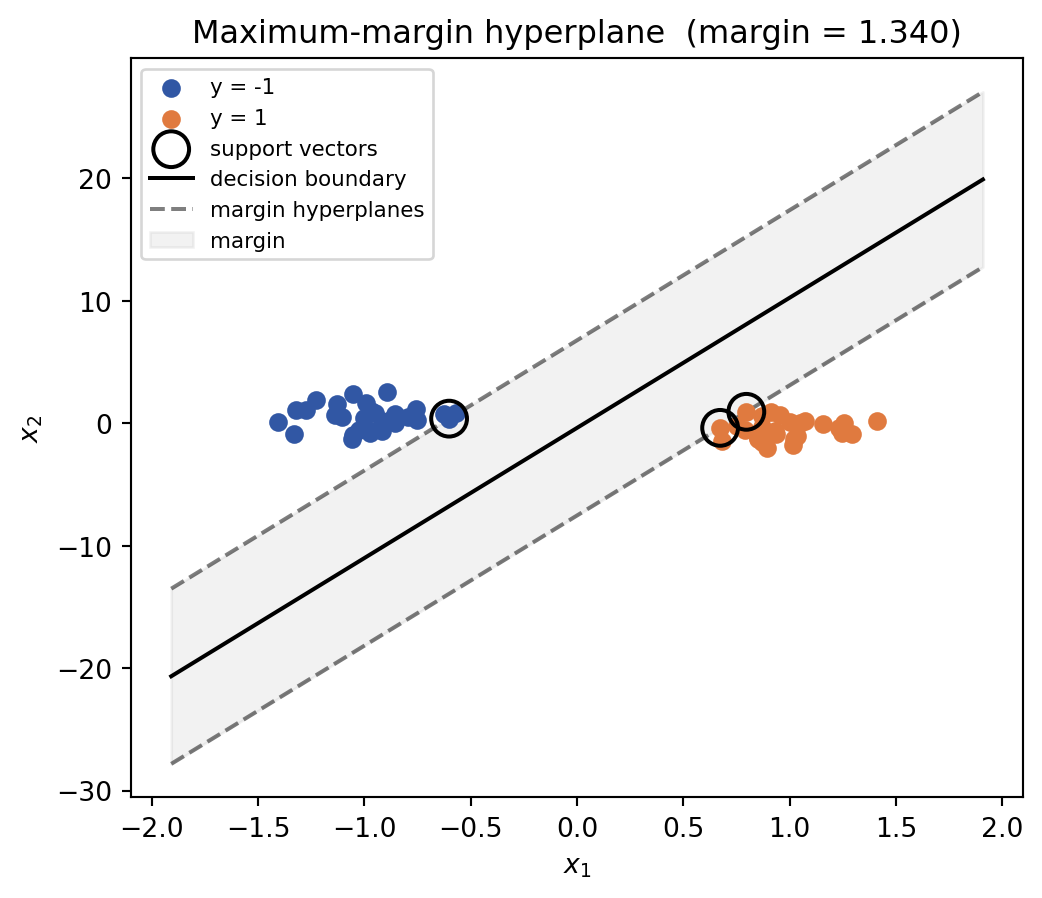

In [3]:
#| label: fig-margin
#| fig-cap: "Maximum-margin hyperplane with margin band and support vectors circled."

model = SVC(kernel='linear', C=1e6)   # large C approximates the hard-margin SVM
model.fit(X, y)

w = model.coef_[0]
b = model.intercept_[0]
margin = 2 / np.linalg.norm(w)

x1 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300)
x2_mid = (-b      - w[0] * x1) / w[1]
x2_pos = ( 1 - b  - w[0] * x1) / w[1]
x2_neg = (-1 - b  - w[0] * x1) / w[1]

fig, ax = plt.subplots(figsize=(6, 5))
for lbl, color in [(-1, '#3157a4'), (1, '#e07a3f')]:
    ax.scatter(*X[y == lbl].T, c=color, label=f'y = {lbl}', zorder=3)
ax.scatter(
    *X[model.support_].T,
    s=180, facecolors='none', edgecolors='k', linewidths=1.5,
    label='support vectors', zorder=4,
)
ax.plot(x1, x2_mid, 'k-',  label='decision boundary')
ax.plot(x1, x2_pos, 'k--', alpha=0.5, label='margin hyperplanes')
ax.plot(x1, x2_neg, 'k--', alpha=0.5)
ax.fill_between(x1, x2_neg, x2_pos, alpha=0.10, color='gray', label='margin')
ax.set(xlabel='$x_1$', ylabel='$x_2$',
       title=f'Maximum-margin hyperplane  (margin = {margin:.3f})')
ax.legend(fontsize=8)
plt.show()

## 3. The dual problem

Introducing a Lagrange multiplier $\alpha_i\geq 0$ for each constraint, the Lagrangian is

$$
L(\mathbf{w},b,\boldsymbol{\alpha})
=\frac{1}{2}\lVert\mathbf{w}\rVert^2
-\sum_{i=1}^{N}\alpha_i\bigl[y_i(\mathbf{w}^\top\mathbf{x}_i+b)-1\bigr].
$$

Setting $\partial L/\partial\mathbf{w}=\mathbf{0}$ and $\partial L/\partial b=0$ yields

$$
\mathbf{w}=\sum_{i=1}^{N}\alpha_i y_i\mathbf{x}_i,
\qquad
\sum_{i=1}^{N}\alpha_i y_i=0.
$$

Substituting back gives the **dual problem**:

$$
\max_{\boldsymbol{\alpha}}\;\sum_{i=1}^{N}\alpha_i
-\frac{1}{2}\sum_{i=1}^{N}\sum_{j=1}^{N}
\alpha_i\alpha_j y_i y_j\,\mathbf{x}_i^\top\mathbf{x}_j
\qquad\text{subject to}\quad
\alpha_i\geq 0,\quad\sum_{i=1}^{N}\alpha_i y_i=0.
$$

By the KKT conditions, $\alpha_i>0$ only for observations on the margin hyperplanes—the **support vectors**. All other $\alpha_i=0$.

In [4]:
print(f'Total observations : {len(y)}')
print(f'Support vectors    : {len(model.support_)}')

# model.dual_coef_ stores alpha_i * y_i; reconstruct w = sum_i alpha_i y_i x_i
w_dual = (model.dual_coef_ @ model.support_vectors_).ravel()

print(f'\nw from dual : {np.round(w_dual, 5)}')
print(f'w from coef_: {np.round(model.coef_[0], 5)}')

Total observations : 60
Support vectors    : 3

w from dual : [ 1.4861  -0.13975]
w from coef_: [ 1.4861  -0.13975]


## 4. Soft-margin SVM

Real datasets are rarely linearly separable. Introducing **slack variables** $\xi_i\geq 0$ allows observations to be inside or on the wrong side of the margin while penalising those violations:

$$
\min_{\mathbf{w},\,b,\,\boldsymbol{\xi}}\;
\frac{1}{2}\lVert\mathbf{w}\rVert^2+C\sum_{i=1}^{N}\xi_i
\qquad\text{subject to}\quad
y_i\bigl(\mathbf{w}^\top\mathbf{x}_i+b\bigr)\geq 1-\xi_i,\quad \xi_i\geq 0.
$$

The parameter $C>0$ governs the trade-off between margin width and training error:

| $C$ | margin | misclassifications |
|-----|--------|--------------------|
| small | wide | many tolerated |
| large | narrow | few tolerated |

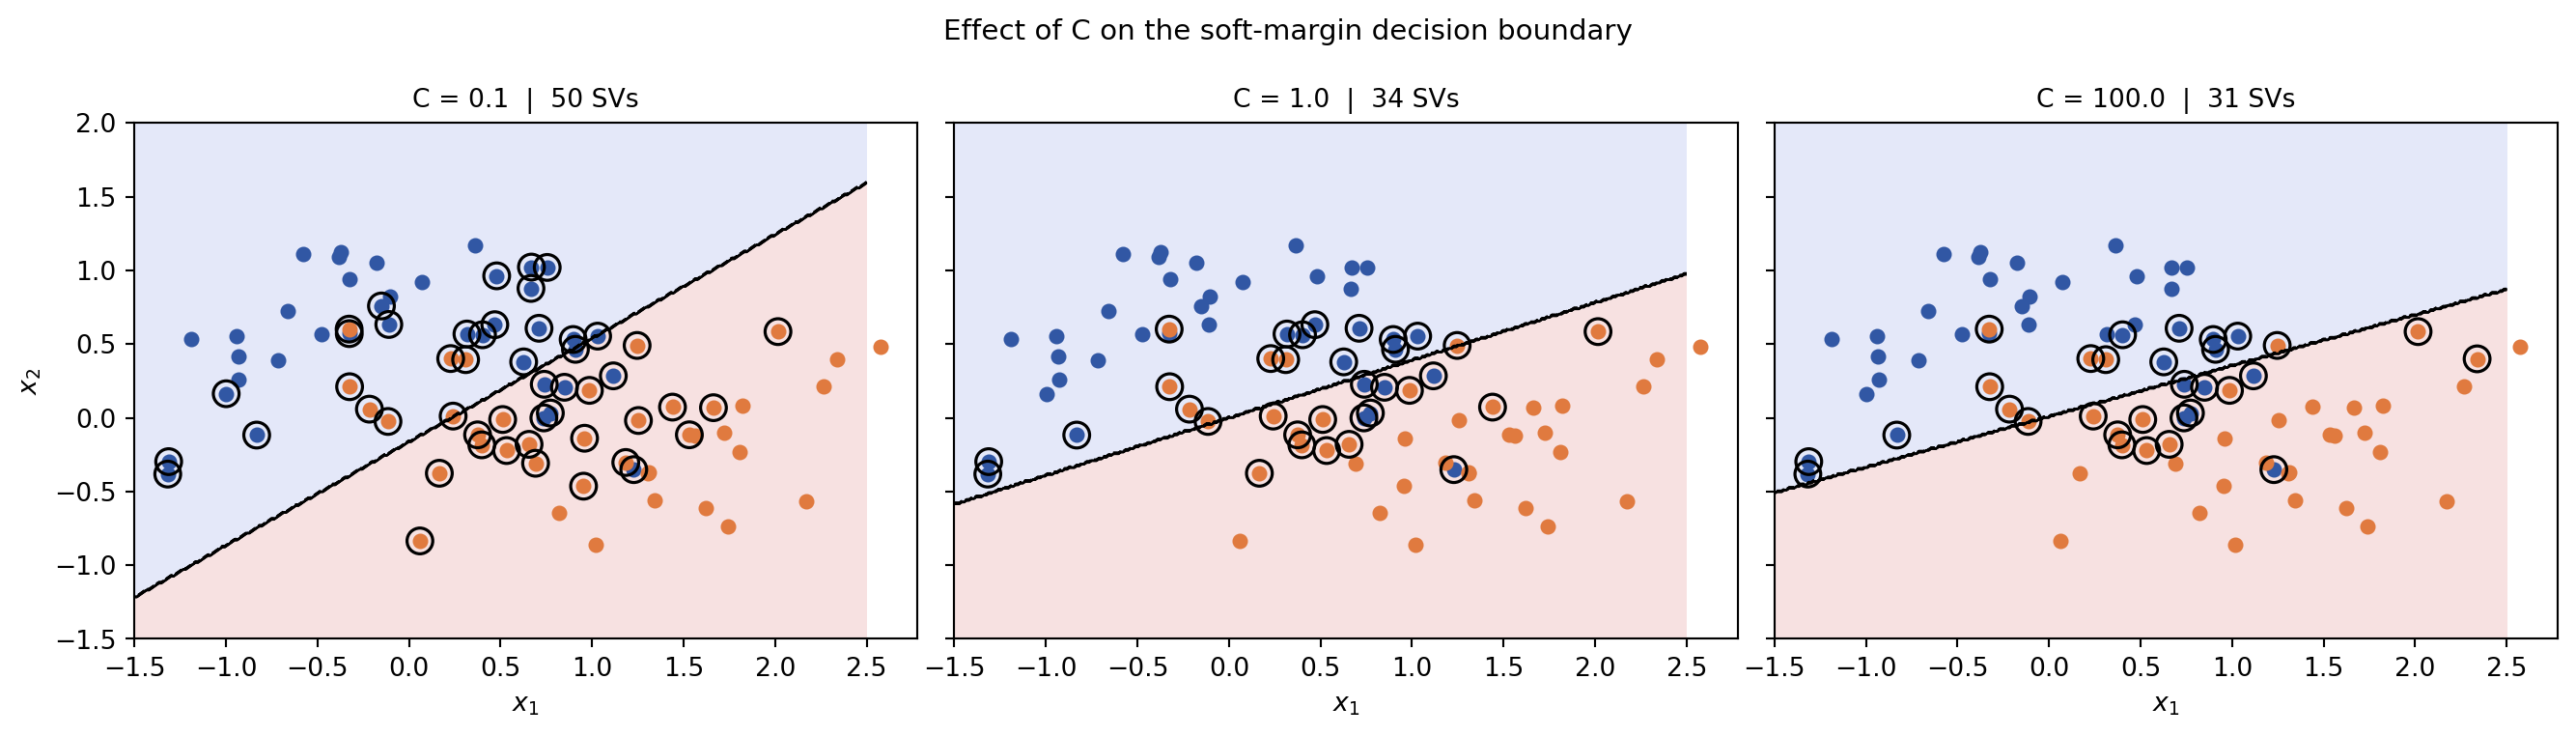

In [5]:
#| label: fig-soft-margin
#| fig-cap: "Decision boundaries and support-vector counts for three values of C."

X_s, y_s = make_moons(n_samples=80, noise=0.25, random_state=RANDOM_SEED)
y_s = 2 * y_s - 1

xx, yy = np.meshgrid(
    np.linspace(-1.5, 2.5, 300),
    np.linspace(-1.5, 2.0, 300),
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, C in zip(axes, [0.1, 1.0, 100.0]):
    clf = SVC(kernel='linear', C=C)
    clf.fit(X_s, y_s)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.15, cmap='coolwarm')
    ax.contour(xx, yy, Z, colors='k', linewidths=0.8)
    for lbl, color in [(-1, '#3157a4'), (1, '#e07a3f')]:
        ax.scatter(*X_s[y_s == lbl].T, c=color, s=25)
    ax.scatter(
        *X_s[clf.support_].T,
        s=100, facecolors='none', edgecolors='k', linewidths=1.2,
    )
    ax.set_title(f'C = {C}  |  {len(clf.support_)} SVs', fontsize=10)
    ax.set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')
fig.suptitle('Effect of C on the soft-margin decision boundary', fontsize=11)
plt.tight_layout()
plt.show()

## Try it yourself

1. Change `RANDOM_SEED` and rerun every cell. Do the same support vectors appear?
2. Increase `cluster_std` in `make_blobs`. At what value does the hard-margin SVM start to struggle?
3. In the soft-margin experiment, raise `noise` in `make_moons` to `0.40`. How does $C$ change the support-vector count?
4. Set `C = 1.0` and switch to `kernel='poly'` with `degree=2`. How does the boundary shape change?